In [2]:
#Task1
import numpy as np
import time

# -----------------------------
# 1. Plain Python list of prices
# -----------------------------
prices = [
    12.5, 18.0, 25.5, 32.0, 45.0,
    52.5, 60.0, 75.0, 80.5, 95.0,
    110.0, 125.5, 140.0, 155.0, 170.5,
    185.0, 200.0, 220.0, 250.0, 300.0
]

tax_rate = 0.08

# Loop-based version
taxed_prices_loop = []

for price in prices:
    taxed_prices_loop.append(price * (1 + tax_rate))

print("Loop-based taxed prices:")
print(taxed_prices_loop)

# -------------------------------------
# 2. NumPy vectorized version (no loop)
# -------------------------------------
prices_np = np.array(prices)

taxed_prices_vectorized = prices_np * (1 + tax_rate)

print("\nVectorized taxed prices:")
print(taxed_prices_vectorized)

# Verify identical results
are_equal = np.allclose(taxed_prices_loop, taxed_prices_vectorized)

print("\nResults identical?", are_equal)

# ----------------------------------------------------
# 3. Boolean masking (no loop, no if statement)
# ----------------------------------------------------
threshold = 50

high_prices = taxed_prices_vectorized[taxed_prices_vectorized > threshold]

print(f"\nTaxed prices above {threshold}:")
print(high_prices)

# Verify all selected values are above threshold
print("All values above threshold?",
      np.all(high_prices > threshold))

# -------------------------------------
# 4. 2D array row sums and column sums
# -------------------------------------
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])

row_sums = matrix.sum(axis=1)
column_sums = matrix.sum(axis=0)

print("\n2D Array:")
print(matrix)

print("\nRow sums:")
print(row_sums)

print("\nColumn sums:")
print(column_sums)

# ==================================================
# Stretch Goal: Performance comparison (1,000,000)
# ==================================================
n = 1_000_000

large_list = list(range(n))

# Loop timing
start = time.perf_counter()

loop_result = []
for x in large_list:
    loop_result.append(x * 1.08)

loop_time = time.perf_counter() - start

# NumPy timing
large_array = np.array(large_list)

start = time.perf_counter()

vector_result = large_array * 1.08

vector_time = time.perf_counter() - start

speedup = loop_time / vector_time

print("\n--- Performance Comparison ---")
print(f"Loop time:      {loop_time:.6f} seconds")
print(f"Vectorized time:{vector_time:.6f} seconds")
print(f"Speedup:        {speedup:.2f}x")


Loop-based taxed prices:
[13.5, 19.44, 27.540000000000003, 34.56, 48.6, 56.7, 64.80000000000001, 81.0, 86.94000000000001, 102.60000000000001, 118.80000000000001, 135.54000000000002, 151.20000000000002, 167.4, 184.14000000000001, 199.8, 216.0, 237.60000000000002, 270.0, 324.0]

Vectorized taxed prices:
[ 13.5   19.44  27.54  34.56  48.6   56.7   64.8   81.    86.94 102.6
 118.8  135.54 151.2  167.4  184.14 199.8  216.   237.6  270.   324.  ]

Results identical? True

Taxed prices above 50:
[ 56.7   64.8   81.    86.94 102.6  118.8  135.54 151.2  167.4  184.14
 199.8  216.   237.6  270.   324.  ]
All values above threshold? True

2D Array:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Row sums:
[10 26 42]

Column sums:
[15 18 21 24]

--- Performance Comparison ---
Loop time:      0.409243 seconds
Vectorized time:0.006577 seconds
Speedup:        62.23x


In [3]:
#Task2
import pandas as pd

# Create sample employee data (15+ rows)
employees = pd.DataFrame({
    "name": [
        "Alice", "Bob", "Charlie", "David", "Emma",
        "Frank", "Grace", "Henry", "Ivy", "Jack",
        "Karen", "Leo", "Mia", "Nathan", "Olivia"
    ],
    "department": [
        "IT", "HR", "Finance", "IT", "HR",
        "Finance", "IT", "Marketing", "Marketing", "HR",
        "IT", "Finance", "Marketing", "IT", "HR"
    ],
    "salary": [
        70000, 50000, 65000, 80000, 55000,
        72000, 90000, 60000, 62000, 58000,
        85000, 75000, 64000, 95000, 61000
    ],
    "years_experience": [
        3, 2, 4, 6, 3,
        5, 8, 2, 3, 4,
        7, 6, 4, 10, 5
    ]
})

# Save to CSV
employees.to_csv("employees.csv", index=False)

# Read CSV
df = pd.read_csv("employees.csv")

print("=== DataFrame Info ===")
print(df.info())

print("\n=== DataFrame Describe ===")
print(df.describe())

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name              15 non-null     object
 1   department        15 non-null     object
 2   salary            15 non-null     int64 
 3   years_experience  15 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 612.0+ bytes
None

=== DataFrame Describe ===
             salary  years_experience
count     15.000000         15.000000
mean   69466.666667          4.800000
std    13228.036603          2.274078
min    50000.000000          2.000000
25%    60500.000000          3.000000
50%    65000.000000          4.000000
75%    77500.000000          6.000000
max    95000.000000         10.000000


In [4]:
#Task3
import pandas as pd
import numpy as np

# ==========================
# Employees DataFrame
# ==========================
employees = pd.DataFrame({
    "name": [
        "Alice", "Bob", "Charlie", "David", "Emma",
        "Frank", "Grace", "Henry", "Ivy", "Jack",
        "Karen", "Leo", "Mia", "Nathan", "Olivia"
    ],
    "department": [
        "IT", "HR", "Finance", "IT", "HR",
        "Finance", "IT", "Marketing", "Marketing", "HR",
        "IT", "Finance", "Marketing", "IT", "HR"
    ],
    "salary": [
        70000, 50000, 65000, 80000, 55000,
        72000, 90000, 60000, 62000, 58000,
        85000, 75000, 64000, 95000, 61000
    ],
    "years_experience": [
        3, 2, 4, 6, 3,
        5, 8, 2, 3, 4,
        7, 6, 4, 10, 5
    ]
})

# ==========================
# Departments DataFrame
# ==========================
departments = pd.DataFrame({
    "department": ["IT", "HR", "Finance", "Marketing"],
    "department_budget": [500000, 200000, 350000, 250000]
})

# ==================================================
# 1. Inner Join
# ==================================================
inner_join = pd.merge(
    employees,
    departments,
    on="department",
    how="inner"
)

print("=== INNER JOIN ===")
print(inner_join)

# ==================================================
# 2. Add employee with unmatched department
# ==================================================
new_employee = pd.DataFrame({
    "name": ["Sophia"],
    "department": ["Legal"],
    "salary": [78000],
    "years_experience": [5]
})

employees_extended = pd.concat(
    [employees, new_employee],
    ignore_index=True
)

left_join = pd.merge(
    employees_extended,
    departments,
    on="department",
    how="left"
)

print("\n=== LEFT JOIN ===")
print(left_join.tail())

# ==================================================
# 3. Introduce missing values
# ==================================================
employees_extended.loc[2, "salary"] = np.nan
employees_extended.loc[8, "years_experience"] = np.nan

print("\n=== MISSING VALUES COUNT ===")
print(employees_extended.isna().sum())

# ==================================================
# 4. Handle missing values
# ==================================================
employees_clean = employees_extended.copy()

employees_clean["salary"] = employees_clean["salary"].fillna(
    employees_clean["salary"].mean()
)

employees_clean["years_experience"] = employees_clean["years_experience"].fillna(
    employees_clean["years_experience"].mean()
)

print("\n=== AFTER HANDLING MISSING VALUES ===")
print(employees_clean.isna().sum())

print("\n=== CLEANED DATA ===")
print(employees_clean.head())

=== INNER JOIN ===
       name department  salary  years_experience  department_budget
0     Alice         IT   70000                 3             500000
1       Bob         HR   50000                 2             200000
2   Charlie    Finance   65000                 4             350000
3     David         IT   80000                 6             500000
4      Emma         HR   55000                 3             200000
5     Frank    Finance   72000                 5             350000
6     Grace         IT   90000                 8             500000
7     Henry  Marketing   60000                 2             250000
8       Ivy  Marketing   62000                 3             250000
9      Jack         HR   58000                 4             200000
10    Karen         IT   85000                 7             500000
11      Leo    Finance   75000                 6             350000
12      Mia  Marketing   64000                 4             250000
13   Nathan         IT   9500

In [5]:
#Task4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Employee DataFrame
employees = pd.DataFrame({
    "name": [
        "Alice", "Bob", "Charlie", "David", "Emma",
        "Frank", "Grace", "Henry", "Ivy", "Jack",
        "Karen", "Leo", "Mia", "Nathan", "Olivia"
    ],
    "department": [
        "IT", "HR", "Finance", "IT", "HR",
        "Finance", "IT", "Marketing", "Marketing", "HR",
        "IT", "Finance", "Marketing", "IT", "HR"
    ],
    "salary": [
        70000, 50000, 65000, 80000, 55000,
        72000, 90000, 60000, 62000, 58000,
        85000, 75000, 64000, 95000, 61000
    ],
    "years_experience": [
        3, 2, 4, 6, 3,
        5, 8, 2, 3, 4,
        7, 6, 4, 10, 5
    ]
})

sns.set_style("whitegrid")

C:\Users\308335\AppData\Local\Temp\ipykernel_25612\123326694.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


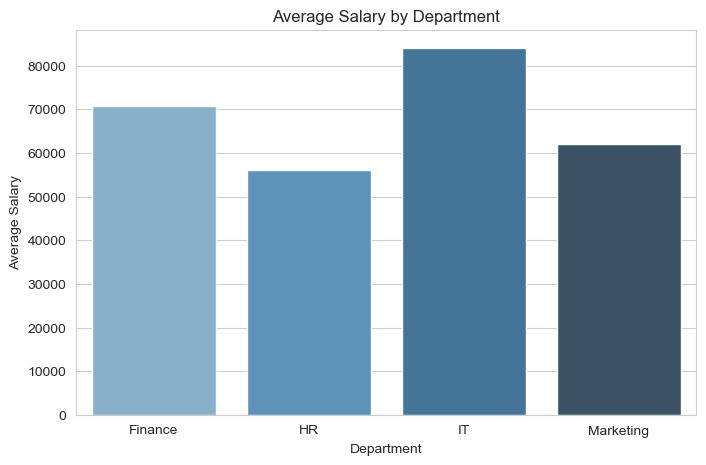

In [6]:
# Bar Chart: Average Salary by Department
avg_salary = (
    employees.groupby("department")["salary"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=avg_salary,
    x="department",
    y="salary",
    palette="Blues_d"
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

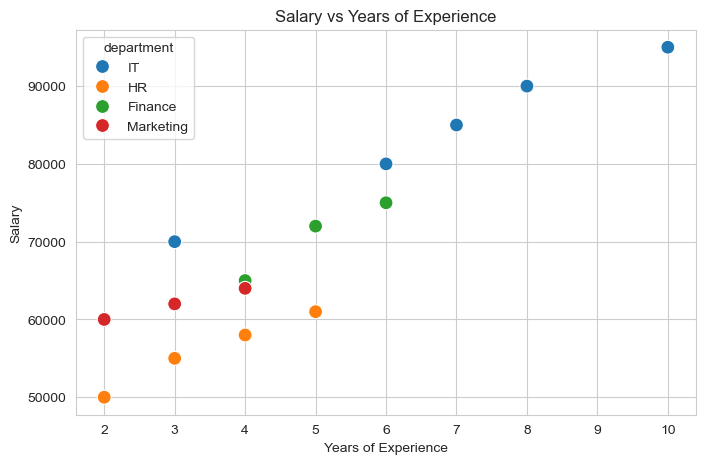

In [7]:
# 2. Scatter Plot: Experience vs Salary
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=employees,
    x="years_experience",
    y="salary",
    hue="department",
    s=100
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

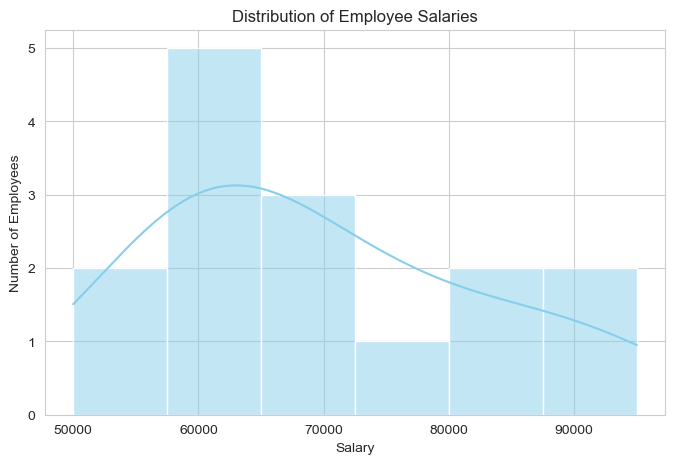

In [8]:
# 3. Histogram: Salary Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    employees["salary"],
    bins=6,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

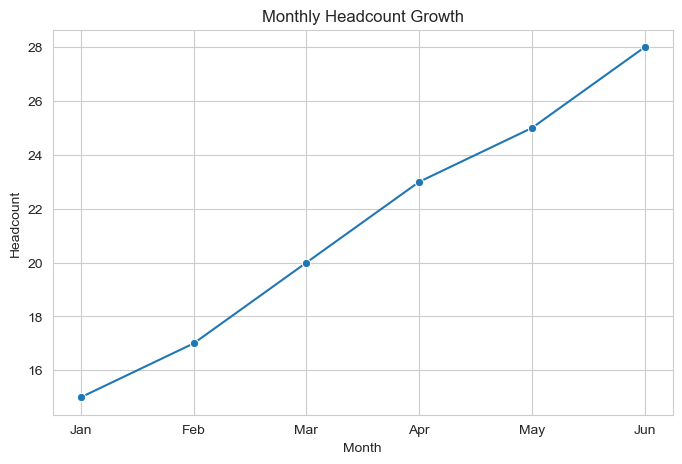

In [9]:
# Stretch Goal: Line Chart Showing Headcount Growth
monthly_headcount = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "headcount": [15, 17, 20, 23, 25, 28]
})

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=monthly_headcount,
    x="month",
    y="headcount",
    marker="o"
)

plt.title("Monthly Headcount Growth")
plt.xlabel("Month")
plt.ylabel("Headcount")
plt.show()

In [ ]:
# Task 5 - Consolidation Reflection


### 1. Java habits I had to unlearn or adjust

#**OOP — Master Class 4:**
    #I had to adjust my Java habit of using explicit getters, setters, and interfaces everywhere. In Python, concepts such as duck typing, direct attribute access, and dunder methods like `__str__` and `__eq__` provide simpler ways to design classes.

#**FastAPI/Testing — Master Class 5:**
    #I had to adjust my Java habit of relying heavily on annotations and framework configuration. With FastAPI, I learned to use Python type hints and Pydantic models for request validation, and testing can be done directly with tools such as `TestClient` and `pytest`.

#**Pandas/NumPy — Master Class 6:**
    #I had to unlearn the habit of processing data mainly with `for` loops. NumPy supports vectorized operations and Pandas provides filtering, `groupby()`, aggregation, and merging, which allow data to be processed more efficiently and concisely.

### 2. Skill I expect to use again

    #One skill I expect to use frequently is **DataFrame filtering and NumPy vectorization**. In upcoming ML/DL modules, datasets will need to be cleaned, filtered, transformed, and prepared before training models, so operations such as boolean masking, handling missing values, and vectorized calculations will be useful during data preprocessing.

### 3. Least confident topic and improvement plan

    #The topic I feel least confident about is **Pandas merging and handling missing data**, especially understanding the differences between inner and left joins and deciding when to use `dropna()` versus `fillna()`. Before the readiness assessment, I will practice several small datasets using `merge()`, `.isna().sum()`, `dropna()`, and `fillna()` and verify the results myself

In [10]:
#Task 6  —  Readiness Self-Check
#1. Attempted From Memory (Before Checking References)
#A. Python Class with a Constructor and a Dunder Method
class Employee:
    def __init__(self, name, department):
        self.name = name
        self.department = department

    def __str__(self):
        return f"Employee(name={self.name}, department={self.department})"


emp = Employee("Alice", "IT")
print(emp)

Employee(name=Alice, department=IT)


In [17]:
!pip install fastapi pydantic

In [19]:
# B. FastAPI Endpoint with a Pydantic Request Model
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

class EmployeeRequest(BaseModel):
    name: str
    age: int

@app.post("/employee")
def create_employee(employee: EmployeeRequest):
    return {
        "message": "Employee created",
        "employee": employee
    }

In [12]:
# C. Pandas groupby().agg() Call
import pandas as pd

summary = (
    df.groupby("department")
      .agg(
          average_salary=("salary", "mean"),
          headcount=("name", "count")
      )
)

print(summary)

            average_salary  headcount
department                           
Finance       70666.666667          3
HR            56000.000000          4
IT            84000.000000          5
Marketing     62000.000000          3
